# Flow Past a Cylinder with XLB (2D)

Welcome! This notebook simulates a classic fluid dynamics problem: flow past a cylinder. We'll use [XLB](https://github.com/Autodesk/XLB), a lattice Boltzmann library, and walk through each step so it's clear not just *what* the code does, but *why*.

**The problem, in plain terms:** fluid flows into one end of a rectangular channel and out the other. Sitting near the inlet is a circular cylinder, blocking part of the flow. At low speeds the fluid would just flow smoothly around it, but at **Re = 200** (a moderate Reynolds number, based on the cylinder's diameter), something more interesting happens: the flow can no longer stay smooth behind the cylinder. It starts shedding vortices alternately from the top and bottom, one after another, in a repeating pattern called a **Kármán vortex street** — the same phenomenon you can sometimes see in clouds passing over an island, or hear as the "singing" of wires in the wind. Because of this, the flow never settles into a fixed shape; it oscillates forever. We'll measure that oscillation directly, by tracking the lift and drag forces on the cylinder over time and figuring out how fast it repeats.

**What we'll do, step by step:**

1. Set up the library (choose the lattice model, backend, and numerical precision)
2. Build a channel that's noticeably longer than it is tall, so the wake has room to develop
3. Translate physical parameters (Reynolds number, cylinder size) into the numbers the solver uses internally
4. Tell the solver where the inlet, outlet, walls, and cylinder are
5. Assemble a "stepper" — the object that advances the simulation by one time step
6. Allocate the arrays that hold the simulation state
7. Run the simulation, measuring the force on the cylinder at every step
8. Look at the wake pattern and the force oscillations, and estimate the shedding frequency

## Prerequisites

Install XLB with JAX support. CPU is fine to follow along and see everything work; a GPU is recommended if you want to run the full simulation length used here in a reasonable amount of time.

In [1]:
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import warp as wp

import xlb
import xlb.velocity_set
from xlb.compute_backend import ComputeBackend
from xlb.grid import grid_factory
from xlb.operator.boundary_condition import (
    ExtrapolationOutflowBC,
    HalfwayBounceBackBC,
    RegularizedBC,
)
from xlb.operator.force.momentum_transfer import MomentumTransfer
from xlb.operator.macroscopic import Macroscopic
from xlb.operator.stepper import IncompressibleNavierStokesStepper
from xlb.precision_policy import PrecisionPolicy

FIG_DIR = Path("figures/flow_past_cylinder_2d")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.figsize": (8, 4), "image.cmap": "twilight"})

---
## Step 1 — Simulation parameters

We start by deciding on the domain size and the physics. The cylinder's diameter `D` is the length scale that defines the Reynolds number:

$$Re = \frac{u_{max} \, D}{\nu}$$

| Parameter | Role |
|-----------|------|
| `grid_shape` | `(nx, ny)` lattice nodes — how fine the grid is, and how long the channel is relative to its height |
| `cyl_diameter` | Cylinder diameter, in lattice cells — bigger means a better-resolved body but a slower simulation |
| `cyl_center` | Where the cylinder sits, placed a few diameters downstream of the inlet, centered vertically |
| `Re`, `u_max` | Reynolds number and the mean inlet speed — together they set the fluid's viscosity |
| `u_peak` | The peak speed of the inlet profile (only relevant if we use a parabolic inlet, see Step 5) |
| `omega` | The relaxation rate used internally by the lattice Boltzmann collision step; derived from viscosity |

One important difference from a lid-driven cavity: at Re = 200 the flow behind the cylinder never stops changing — it sheds vortices forever. So there's no "wait until it stops moving" condition to check for. Instead, we simply decide how many times we want the flow to cross the whole domain (`flow_pass = grid_shape[0] / u_peak` gives the number of steps for one crossing) and run for a fixed multiple of that.

In [2]:
ny = 128
nx = int(3 * ny)  # length : height
grid_shape = (nx, ny)

compute_backend = ComputeBackend.JAX
precision_policy = PrecisionPolicy.FP64FP64

velocity_set = xlb.velocity_set.D2Q9(
    precision_policy=precision_policy,
    compute_backend=compute_backend,
)

Re = 200.0
u_max = 0.05  # mean inlet speed in lattice units
u_peak = 1.5 * u_max  # peak speed of the parabolic inlet profile
cyl_diameter = int(ny / 8)  # cylinder diameter in lattice cells
cyl_center = (nx // 4, ny // 2)  # ~4 diameters downstream of the inlet, mid-height

inlet_profile = "flat"  # "parabolic" (Poiseuille) or "flat" (uniform)

visc = u_max * cyl_diameter / Re
omega = 1.0 / (3.0 * visc + 0.5)

flow_pass = int(grid_shape[0] / u_peak)  # steps for the flow to cross the domain once

print(f"Grid:             {grid_shape[0]} x {grid_shape[1]} (length:height = {grid_shape[0] / grid_shape[1]:.1f})")
print(f"Velocity set:     D2Q9 ({velocity_set.q} populations per node)")
print(f"Re:               {Re}")
print(f"Cylinder diam.:   {cyl_diameter} cells ({cyl_diameter / grid_shape[1]:.3f} of the channel height)")
print(f"Inlet profile:    {inlet_profile}")
print(f"Mean inlet speed: {u_max}")
print(f"Peak inlet speed: {u_peak}")
print(f"Viscosity nu:     {visc:.6e}")
print(f"Relaxation omega: {omega:.6f}")
print(f"Flow-pass steps:  {flow_pass}")

Grid:             384 x 128 (length:height = 3.0)
Velocity set:     D2Q9 (9 populations per node)
Re:               200.0
Cylinder diam.:   16 cells (0.125 of the channel height)
Inlet profile:    flat
Mean inlet speed: 0.05
Peak inlet speed: 0.07500000000000001
Viscosity nu:     4.000000e-03
Relaxation omega: 1.953125
Flow-pass steps:  5119


---
## Step 2 — Initialize XLB (`xlb.init`)

`xlb.init(...)` tells the library which lattice model, backend, and numerical precision to use by default. Any operator we create afterward falls back to these choices unless we explicitly override them. Call this once, right at the start of your script or notebook.

In [3]:
xlb.init(
    velocity_set=velocity_set,
    default_backend=compute_backend,
    default_precision_policy=precision_policy,
)

No GPU support is available; CPU fallback will be used.


---
## Step 3 — Create the grid (`grid_factory`)

The grid is the container that holds all of our field arrays and knows the domain's shape. Population arrays will have shape `(q, nx, ny)` — one 2D slice per lattice direction.

In [4]:
grid = grid_factory(grid_shape, compute_backend=compute_backend)
print(f"Grid type: {type(grid).__name__}")
print(f"Shape:     {grid.shape}")

Grid type: JaxGrid
Shape:     (384, 128)


---
## Step 4 — Boundary indices

This is an **external/channel flow** rather than a closed box, so we have four distinct kinds of boundary to define, each described as a list of grid indices:

- **Inlet (left):** fluid enters here at a prescribed velocity — we'll use `RegularizedBC("velocity", ...)`
- **Outlet (right):** fluid should be able to leave freely, without bouncing back and corrupting the simulation — `ExtrapolationOutflowBC` extrapolates from the interior instead of pinning a fixed condition
- **Top/bottom walls:** stationary no-slip boundaries, same idea as the cavity walls — `HalfwayBounceBackBC`
- **Cylinder:** also a no-slip solid body, `HalfwayBounceBackBC` — we'll reuse this same boundary condition object later to measure the force the fluid exerts on it

To find the cylinder's nodes, we build a simple circular mask: any grid point within `cyl_radius` of `cyl_center` counts as "inside the cylinder."

In [5]:
box = grid.bounding_box_indices()
box_no_edge = grid.bounding_box_indices(remove_edges=True)

inlet = box_no_edge["left"]
outlet = box_no_edge["right"]
walls = [box["bottom"][i] + box["top"][i] for i in range(velocity_set.d)]
walls = np.unique(np.array(walls), axis=-1).tolist()

cyl_radius = cyl_diameter / 2.0
x = np.arange(grid_shape[0])
y = np.arange(grid_shape[1])
X, Y = np.meshgrid(x, y, indexing="ij")
cyl_mask = (X - cyl_center[0]) ** 2 + (Y - cyl_center[1]) ** 2 < cyl_radius**2
cyl_indices_arr = np.where(cyl_mask)
cylinder = [tuple(cyl_indices_arr[i].tolist()) for i in range(velocity_set.d)]

print(f"Inlet nodes:    {len(inlet[0])}")
print(f"Outlet nodes:   {len(outlet[0])}")
print(f"Wall nodes:     {len(walls[0])}")
print(f"Cylinder nodes: {len(cylinder[0])}")

Inlet nodes:    126
Outlet nodes:   126
Wall nodes:     768
Cylinder nodes: 193


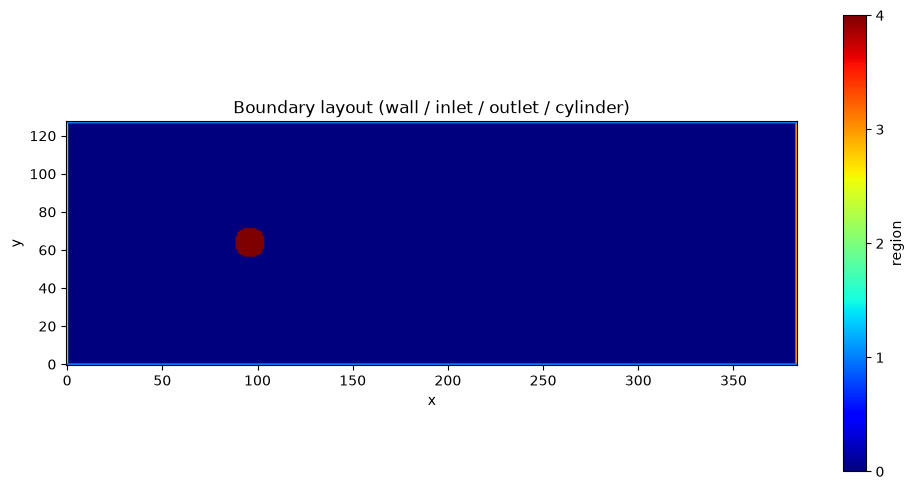

In [6]:
# Visualize where each BC is applied
bc_map = np.zeros(grid_shape, dtype=int)  # 0 = interior, 1 = wall, 2 = inlet, 3 = outlet, 4 = cylinder
for i in range(len(walls[0])):
    bc_map[walls[0][i], walls[1][i]] = 1
for i in range(len(inlet[0])):
    bc_map[inlet[0][i], inlet[1][i]] = 2
for i in range(len(outlet[0])):
    bc_map[outlet[0][i], outlet[1][i]] = 3
for i in range(len(cylinder[0])):
    bc_map[cylinder[0][i], cylinder[1][i]] = 4

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(bc_map.T, origin="lower", cmap="jet", vmin=0, vmax=4)
ax.set_title("Boundary layout (wall / inlet / outlet / cylinder)")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im, ax=ax, ticks=[0, 1, 2, 3, 4], label="region")
fig.tight_layout()
fig.savefig(FIG_DIR / "00_boundary_layout.png", dpi=150)
plt.show()

---
## Step 5 — Boundary condition objects

Now we turn the index lists into actual boundary-condition operators:

| BC | Region | Effect |
|----|--------|--------|
| `RegularizedBC("velocity", profile=...)` | Inlet | Prescribes the inflow velocity profile |
| `ExtrapolationOutflowBC` | Outlet | Lets the wake exit smoothly, without spurious reflections bouncing back into the domain |
| `HalfwayBounceBackBC` | Top/bottom walls | No-slip channel walls |
| `HalfwayBounceBackBC` | Cylinder | No-slip solid body; also used later to compute drag/lift |

For the inlet, there are two common choices for how the incoming velocity is distributed across the channel height, and `bc_profile()` below lets you pick either one via the `inlet_profile` flag set in Step 1:

- `"parabolic"` — a Poiseuille profile: fastest in the middle of the channel, tapering smoothly to zero at the walls, peaking at `u_peak = 1.5 * u_max`. This is the more physically realistic choice for flow that has already developed inside a pipe or channel.
- `"flat"` — a uniform inflow at `u_max` everywhere across the inlet. This is the simpler, more idealized choice often used in textbook cylinder benchmarks, representing fluid arriving from a large open reservoir.

Both are implemented for the JAX and Warp backends, even though this notebook only runs the JAX one — so the same code will work unchanged if you switch backends later.

In [7]:
def bc_profile():
    """Inlet profile, switching on `inlet_profile`:
    - "parabolic": Poiseuille profile, u_x = 4 u_peak / H^2 * (y H - y^2), zero at the walls.
    - "flat":      uniform profile, u_x = u_max everywhere.
    """
    channel_height = float(grid_shape[1] - 1)

    if compute_backend == ComputeBackend.JAX:
        if inlet_profile == "parabolic":

            def bc_profile_jax():
                y = jnp.arange(grid_shape[1])
                u_x = jnp.maximum(
                    0.0,
                    4.0 * u_peak / channel_height**2 * (y * channel_height - y**2),
                )
                u_y = jnp.zeros_like(u_x)
                return jnp.stack([u_x, u_y])

        elif inlet_profile == "flat":

            def bc_profile_jax():
                y = jnp.arange(grid_shape[1])
                u_x = jnp.full_like(y, u_max, dtype=jnp.result_type(float))
                u_y = jnp.zeros_like(u_x)
                return jnp.stack([u_x, u_y])

        else:
            raise ValueError(f"Unknown inlet_profile: {inlet_profile!r}")

        return bc_profile_jax

    wp_dtype = precision_policy.compute_precision.wp_dtype
    ch = wp_dtype(channel_height)
    four = wp_dtype(4.0)
    u_peak_wp = wp_dtype(u_peak)
    u_max_wp = wp_dtype(u_max)

    if inlet_profile == "parabolic":

        @wp.func
        def bc_profile_warp(index: wp.vec3i):
            y = wp_dtype(index[1])
            u_x = four * u_peak_wp / (ch * ch) * (y * ch - y * y)
            return wp.vec(wp.max(wp_dtype(0.0), u_x), length=1)

    elif inlet_profile == "flat":

        @wp.func
        def bc_profile_warp(index: wp.vec3i):
            return wp.vec(u_max_wp, length=1)

    else:
        raise ValueError(f"Unknown inlet_profile: {inlet_profile!r}")

    return bc_profile_warp


bc_inlet = RegularizedBC("velocity", profile=bc_profile(), indices=inlet)
bc_outlet = ExtrapolationOutflowBC(indices=outlet)
bc_walls = HalfwayBounceBackBC(indices=walls)
bc_cylinder = HalfwayBounceBackBC(indices=cylinder)
boundary_conditions = [bc_walls, bc_inlet, bc_outlet, bc_cylinder]

print(boundary_conditions)

registered bc RegularizedBC_300024461 with id 1
registered bc ExtrapolationOutflowBC_300024536 with id 2
registered bc HalfwayBounceBackBC_299985642 with id 3
WARNING! Assuming no-slip condition for BC type = HalfwayBounceBackBC!
registered bc HalfwayBounceBackBC_300005230 with id 4
WARNING! Assuming no-slip condition for BC type = HalfwayBounceBackBC!
[HalfwayBounceBackBC(), RegularizedBC(), ExtrapolationOutflowBC(), HalfwayBounceBackBC()]


---
## Step 6 — Build the stepper

`IncompressibleNavierStokesStepper` bundles streaming, boundary conditions, collision, and everything in between into one object you call once per time step. It doesn't care whether the underlying lattice is 2D or 3D — the same stepper class works for this D2Q9 cylinder case as it would for a fully three-dimensional flow.

In [8]:
stepper = IncompressibleNavierStokesStepper(
    grid=grid,
    boundary_conditions=boundary_conditions,
    collision_type="BGK",
)
print(f"Streaming scheme: {stepper.streaming_scheme}")
print(f"Collision:        {type(stepper.collision).__name__}")

Streaming scheme: pull
Collision:        BGK


---
## Step 7 — Prepare fields

`prepare_fields()` allocates everything the time loop needs: the double-buffered populations `f_0`/`f_1`, the `bc_mask` (which boundary condition applies at each node), and the `missing_mask` (which incoming directions are blocked by a wall). Everything starts at uniform equilibrium — density ρ = 1, velocity **u** = 0 — representing fluid at rest before we turn the inlet on.

In [9]:
f_0, f_1, bc_mask, missing_mask = stepper.prepare_fields()

print(f"f_0 shape:          {f_0.shape}")
print(f"f_1 shape:          {f_1.shape}")
print(f"bc_mask shape:      {bc_mask.shape}, dtype={bc_mask.dtype}")
print(f"missing_mask shape: {missing_mask.shape}, dtype={missing_mask.dtype}")

Warp 1.16.0 initialized:
   CUDA not enabled in this build
   Devices:
     "cpu"      : "arm"
   Kernel cache:
     /Users/rivas/Library/Caches/warp/1.16.0
f_0 shape:          (9, 384, 128)
f_1 shape:          (9, 384, 128)
bc_mask shape:      (1, 384, 128), dtype=uint8
missing_mask shape: (9, 384, 128), dtype=bool


In [10]:
macro = Macroscopic(
    compute_backend=compute_backend,
    precision_policy=precision_policy,
    velocity_set=velocity_set,
)


def recover_macroscopic(f):
    """Recover rho and u from populations using the Macroscopic operator."""
    return macro(f)


def vorticity_z(u):
    """2D vorticity omega_z = d(u_y)/dx - d(u_x)/dy, u has shape (2, nx, ny)."""
    du_y_dx = jnp.gradient(u[1], axis=0)
    du_x_dy = jnp.gradient(u[0], axis=1)
    return du_y_dx - du_x_dy


def plot_velocity_magnitude(f, title, save_path=None):
    """Recover velocity and plot |u| (interior nodes only)."""
    _, u = recover_macroscopic(f)
    u = u[:, 1:-1, 1:-1]
    u_mag = jnp.sqrt(u[0] ** 2 + u[1] ** 2)

    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(u_mag.T, origin="lower")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(im, ax=ax, label="|u|")
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150)
    plt.show()

    return u_mag

---
## Step 8 — Momentum exchange for drag and lift

To know how hard the fluid is pushing on the cylinder, we use `MomentumTransfer` — an operator that computes the force on a no-slip boundary using the momentum-exchange method (essentially: track how much momentum the fluid loses or gains each time it bounces off the solid surface). We attach it to `bc_cylinder`, the same boundary-condition object we defined in Step 5.

In 2D, the returned force has two components: `force[0]` is drag (pushing the cylinder downstream, along x) and `force[1]` is lift (pushing it sideways, along y).

Drag and lift coefficients are the standard way to report these forces without the value being tied to a specific fluid speed or cylinder size. In 2D, we normalize by the cylinder's diameter (its "frontal area" per unit length):

$$C_D = \frac{2 F_x}{u_{max}^2\, D}, \qquad C_L = \frac{2 F_y}{u_{max}^2\, D}$$

In [11]:
momentum_transfer = MomentumTransfer(bc_cylinder, compute_backend=compute_backend)

def drag_lift_coefficients(f_0, f_1, bc_mask, missing_mask):
    force = momentum_transfer(f_0, f_1, bc_mask, missing_mask)
    cd = 2.0 * force[0] / (u_max**2 * cyl_diameter)
    cl = 2.0 * force[1] / (u_max**2 * cyl_diameter)
    return float(cd), float(cl)

---
## Step 9 — The time loop

As mentioned in Step 1, at Re = 200 this flow never settles — it sheds vortices forever, so there's no convergence check to wait for. Instead we advance for a fixed number of steps (a set number of full domain crossings, `num_steps = 8 * flow_pass`), recording $C_D$ and $C_L$ at every single step, since that's cheap. Every `snapshot_interval` steps, we also save a full snapshot of the velocity field, which we'll use afterward for the wake visualizations.

We don't plot anything while the loop is running — we just collect what we need in memory first and do all the plotting afterward, once the run is done.

In [12]:
num_steps = 8 * flow_pass
snapshot_interval = int(0.1 * flow_pass)
snapshot_steps = list(range(0, num_steps + 1, snapshot_interval))

print(f"num_steps:         {num_steps}")
print(f"snapshot_interval: {snapshot_interval}")

cd_history = np.zeros(num_steps + 1)
cl_history = np.zeros(num_steps + 1)
snapshots = {}

for step in range(num_steps + 1):
    cd, cl = drag_lift_coefficients(f_0, f_1, bc_mask, missing_mask)
    cd_history[step] = cd
    cl_history[step] = cl

    if step in snapshot_steps:
        _, u_snap = recover_macroscopic(f_0)
        snapshots[step] = np.asarray(u_snap)
        print(f"Step {step:6d}: Cd={cd:.4f}, Cl={cl:.4f}", end="\r")

    if step == num_steps:
        break

    f_0, f_1 = stepper(f_0, f_1, bc_mask, missing_mask, omega, step)
    f_0, f_1 = f_1, f_0

num_steps:         40952
snapshot_interval: 511


---
## Step 10 — Post-processing

Now let's see what we got. We'll look at three things:

1. Velocity-magnitude and vorticity snapshots, to actually *see* the wake and the vortex shedding
2. The drag and lift coefficient histories over time, which should show a clear oscillation once transients have died down
3. An estimate of the shedding frequency (the Strouhal number), pulled out of the lift-coefficient oscillation via FFT

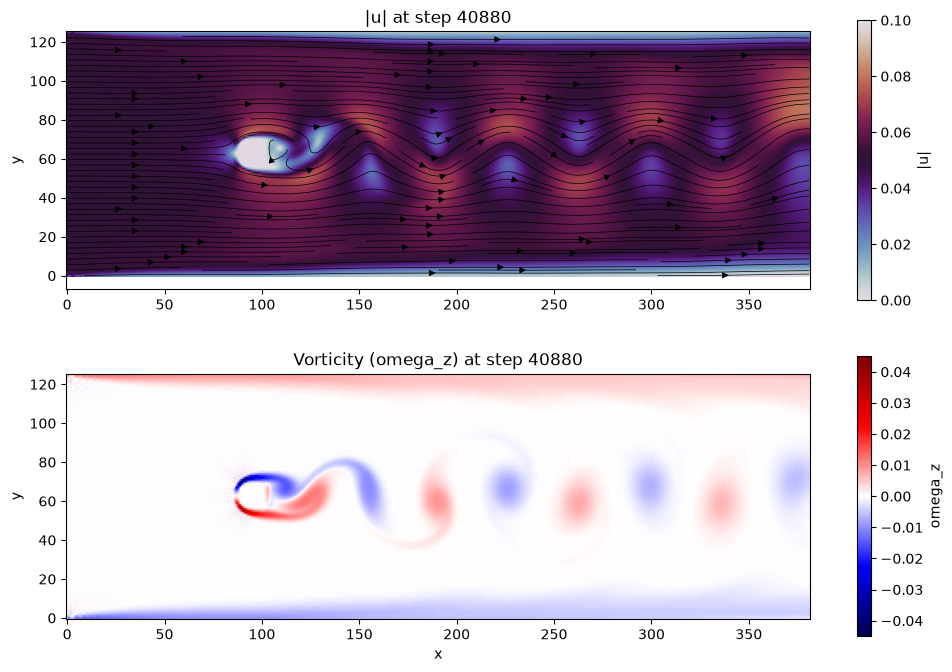

In [13]:
from IPython.display import clear_output as clc

for tt in range(0, len(snapshots), 1):
    step = list(snapshots.keys())[tt]
    u_snap = snapshots[step][:, 1:-1, 1:-1]
    u_mag = np.sqrt(u_snap[0] ** 2 + u_snap[1] ** 2)
    vorticity = vorticity_z(u_snap)

    fig, axs = plt.subplots(2, 1, figsize=(12, 8))

    ax = axs[0]
    im = ax.imshow(u_mag.T, origin="lower", vmin=0, vmax=0.1)
    ax.streamplot(
        np.arange(u_snap.shape[1]),
        np.arange(u_snap.shape[2]),
        u_snap[0].T,
        u_snap[1].T,
        color="k",
        density=1.5,
        linewidth=0.5,
    )
    ax.set_title(f"|u| at step {step}")
    ax.set_ylabel("y")
    fig.colorbar(im, ax=ax, label="|u|")

    ax = axs[1]
    im = ax.imshow(vorticity.T, origin="lower", cmap="seismic", vmin=-0.045, vmax=0.045)
    ax.set_title(f"Vorticity (omega_z) at step {step}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(im, ax=ax, label="omega_z")

    fig.savefig(FIG_DIR / f"velocity_magnitude_step_{step}.png", dpi=150)
    plt.show()
    clc(wait=True)
    plt.close(fig)

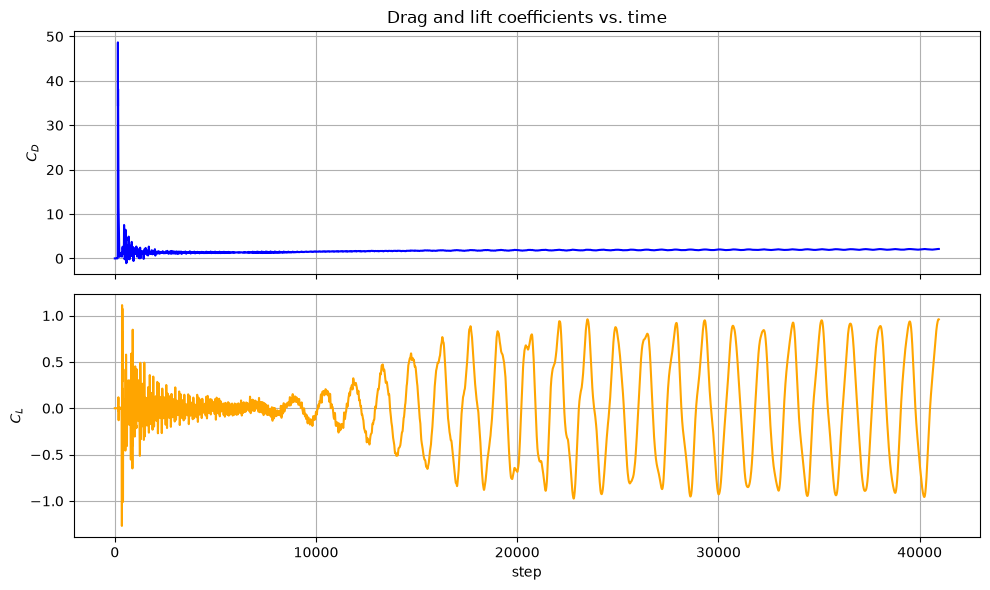

Mean Cd (settled): 1.9496
Cl amplitude (settled): 0.9677


In [14]:
steps_axis = np.arange(num_steps + 1)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(steps_axis, cd_history, color="blue")
axes[0].set_ylabel("$C_D$")
axes[0].set_title("Drag and lift coefficients vs. time")
axes[0].grid(True)

axes[1].plot(steps_axis, cl_history, color="orange")
axes[1].set_ylabel("$C_L$")
axes[1].set_xlabel("step")
axes[1].grid(True)

fig.tight_layout()
fig.savefig(FIG_DIR / "drag_lift_history.png", dpi=150)
plt.show()

# Use the second half of the run (transients washed out) for mean/statistics
settled = steps_axis > num_steps // 2
print(f"Mean Cd (settled): {cd_history[settled].mean():.4f}")
print(f"Cl amplitude (settled): {(cl_history[settled].max() - cl_history[settled].min()) / 2:.4f}")

### Strouhal number

The Strouhal number is a compact, dimensionless way to describe how fast the vortex shedding oscillates:

$$St = \frac{f\, D}{u_{max}}$$

where $f$ is the shedding frequency. We find $f$ by taking an FFT of the settled portion of $C_L(t)$ (the part after transients have died out) and picking the strongest peak. For Re = 200, experiments and simulations consistently report $St \approx 0.19$–$0.20$ — if our number lands near there, that's a good sign the simulation captured the physics correctly.

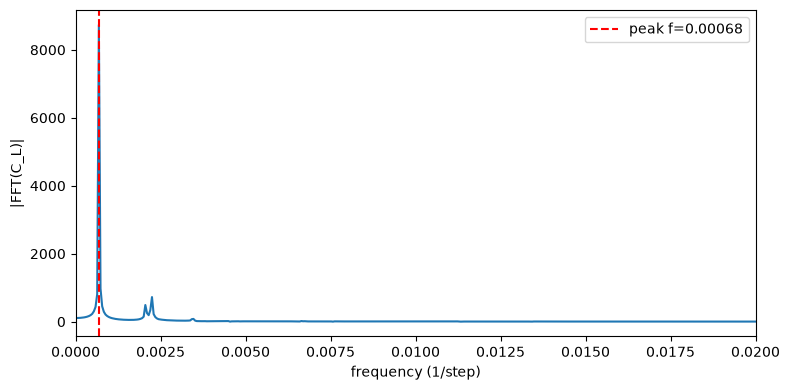

Shedding frequency: 0.000684 (1/step)
Strouhal number St = f*D/u_max: 0.2188
Reference (Re=200, literature): St ~ 0.19-0.20


In [15]:
cl_settled = cl_history[settled] - cl_history[settled].mean()
n = len(cl_settled)

spectrum = np.abs(np.fft.rfft(cl_settled))
freqs = np.fft.rfftfreq(n, d=1.0)  # frequency in cycles per lattice timestep

# Ignore the zero-frequency bin
peak_idx = np.argmax(spectrum[1:]) + 1
f_shedding = freqs[peak_idx]
strouhal = f_shedding * cyl_diameter / u_max

fig, ax = plt.subplots()
ax.plot(freqs[1:], spectrum[1:])
ax.axvline(f_shedding, color="red", linestyle="--", label=f"peak f={f_shedding:.5f}")
ax.set_xlabel("frequency (1/step)")
ax.set_ylabel("|FFT(C_L)|")
ax.set_xlim(0, 0.02)
ax.legend()
fig.tight_layout()
plt.show()

print(f"Shedding frequency: {f_shedding:.6f} (1/step)")
print(f"Strouhal number St = f*D/u_max: {strouhal:.4f}")
print("Reference (Re=200, literature): St ~ 0.19-0.20")